### Explore the data from the Hierarchical brain network model

Neuron Paper, Demirtas et al., 2019

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.io import Data
import pandas as pd
import h5py

In [2]:
# Load the data
data_handler = Data("data/", "outputs/")
hdf5_file = data_handler.load('demirtas_neuron_2019.hdf5')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/demirtas_neuron_2019.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [4]:
# See what's in the root of the file
print("Root keys:", list(hdf5_file.keys()))

Root keys: ['alphabeta_removed_meg_pc1', 'apprx_posterior_heterogeneous', 'apprx_posterior_homogeneous', 'fc', 'fc_heterogeneous', 'fc_homogeneous', 'heterogeneity_maps', 'raw_meg_pc1', 'sc', 't1wt2w']


In [5]:
# Check each dataset's properties
for key in hdf5_file.keys():
    if isinstance(hdf5_file[key], h5py.Dataset):
        dset = hdf5_file[key]
        print(f"{key}: shape={dset.shape}, dtype={dset.dtype}")
        
        # Data range for numerical data
        if np.issubdtype(dset.dtype, np.number):
            data = dset[...]  # Load the data
            print(f"  Range: {data.min():.4f} to {data.max():.4f}")

alphabeta_removed_meg_pc1: shape=(360,), dtype=float64
  Range: -0.4938 to 0.9336
apprx_posterior_heterogeneous: shape=(6, 1000), dtype=float64
  Range: 0.0332 to 6.0711
apprx_posterior_homogeneous: shape=(4, 1000), dtype=float64
  Range: 1.3928 to 11.4652
fc: shape=(360, 360), dtype=float64
  Range: -0.2116 to 1.0000
fc_heterogeneous: shape=(2, 180, 180), dtype=float64
  Range: 0.0000 to 0.9066
fc_homogeneous: shape=(2, 180, 180), dtype=float64
  Range: 0.0000 to 0.8323
heterogeneity_maps: shape=(360, 10), dtype=float64
  Range: -0.0000 to 1.0000
raw_meg_pc1: shape=(360,), dtype=float64
  Range: -0.7094 to 0.7381
sc: shape=(360, 360), dtype=float64
  Range: 0.0000 to 85.8243
t1wt2w: shape=(360,), dtype=float64
  Range: 1.0899 to 1.7449


In [6]:
# Load structural connectivity
sc = hdf5_file['sc'][:]
print(f"Structural connectivity shape: {sc.shape}")
print(f"SC range: {sc.min():.4f} to {sc.max():.4f}")

# Load functional connectivity
fc = hdf5_file['fc'][:]
print(f"Functional connectivity shape: {fc.shape}")

# Load T1w/T2w heterogeneity map
t1wt2w = hdf5_file['t1wt2w'][:]
print(f"T1w/T2w map shape: {t1wt2w.shape}")
print(f"T1w/T2w range: {t1wt2w.min():.4f} to {t1wt2w.max():.4f}")


Structural connectivity shape: (360, 360)
SC range: 0.0000 to 85.8243
Functional connectivity shape: (360, 360)
T1w/T2w map shape: (360,)
T1w/T2w range: 1.0899 to 1.7449


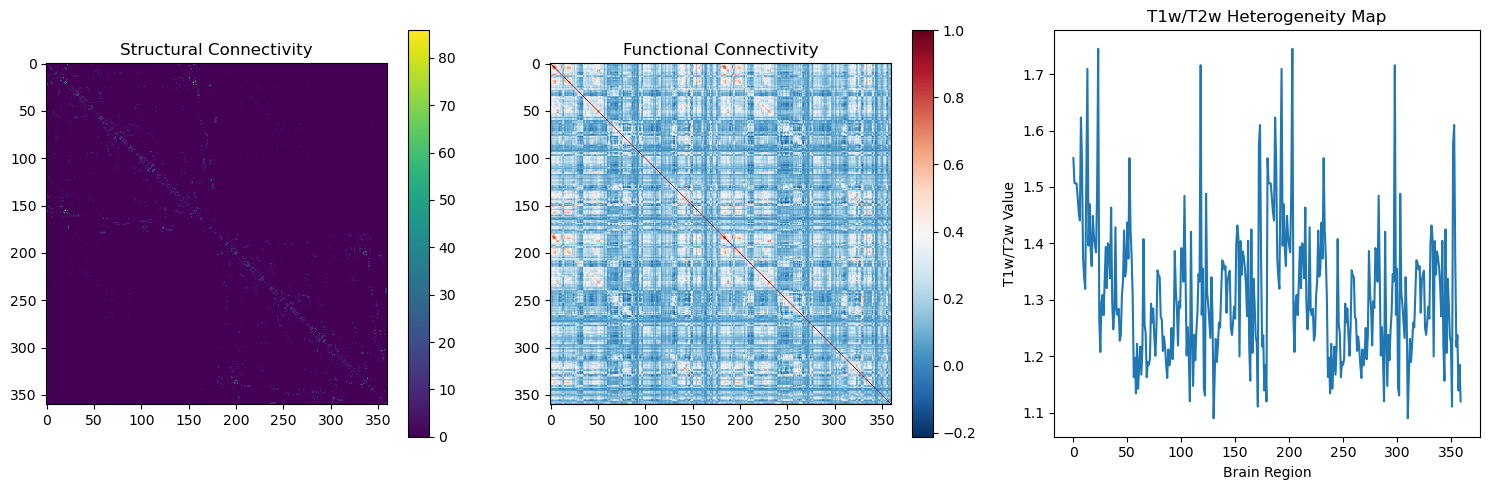

In [7]:
# Visualize the connectivity matrices
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sc, cmap='viridis')
plt.title('Structural Connectivity')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(fc, cmap='RdBu_r')
plt.title('Functional Connectivity')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.plot(t1wt2w)
plt.title('T1w/T2w Heterogeneity Map')
plt.xlabel('Brain Region')
plt.ylabel('T1w/T2w Value')

plt.tight_layout()
plt.show()

In [12]:
theta_het = hdf5_file['apprx_posterior_heterogeneous'][:]

In [17]:
theta_het[0,0]

np.float64(1.1236402696179273)

## Matrix Plotting

In [40]:
def matrix_plot_d(ax, x, cmap):
    ax.pcolormesh(x, cmap=cmap, vmin=0.0, vmax=1.0)
    ax.set_aspect(1)
    # set axis limits to fit data
    ax.set_xlim([0, x.shape[1]])
    ax.set_ylim([0, x.shape[0]])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

def matrix_plot_f(ax, x, cmap):
    ax.pcolormesh(x, cmap=cmap, vmin=x.min(), vmax=x.max())
    ax.set_aspect(1)
    # set axis limits to fit data
    ax.set_xlim([0, x.shape[1]])
    ax.set_ylim([0, x.shape[0]])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [41]:
fc = hdf5_file['fc'][:]
print(f"Range: {fc.min():.3f} to {fc.max():.3f}")

Range: -0.212 to 1.000


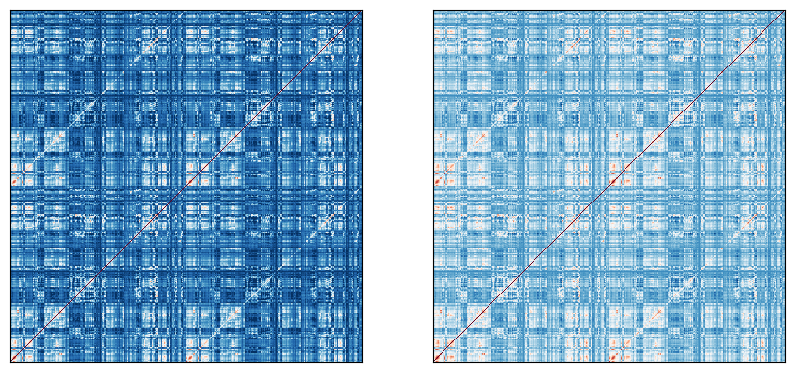

In [44]:
fig, ax = plt.subplots(1,2, figsize=(10, 8))
matrix_plot_d(ax[0], fc, 'RdBu_r')
matrix_plot_f(ax[1], fc, 'RdBu_r')

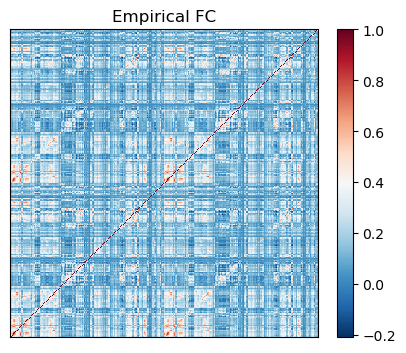

In [48]:
def matrix_plot(ax, x, cmap):
    im = ax.pcolormesh(x, cmap=cmap, vmin=x.min(), vmax=x.max())
    ax.set_aspect(1)
    ax.set_xlim([0, x.shape[1]])
    ax.set_ylim([0, x.shape[0]])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    return im  # Return this so you can add colorbar later

fig, ax = plt.subplots(figsize=(5, 4))

im1 = matrix_plot(ax, fc, 'RdBu_r')
ax.set_title('Empirical FC')
plt.colorbar(im1, ax=ax)  # Add colorbar to this specific subplot

In [34]:
def matrix_plot_2(ax, x, cmap):
    ax.matshow(x, cmap=cmap, vmin=0.0, vmax=1.0)
    ax.axis('off')

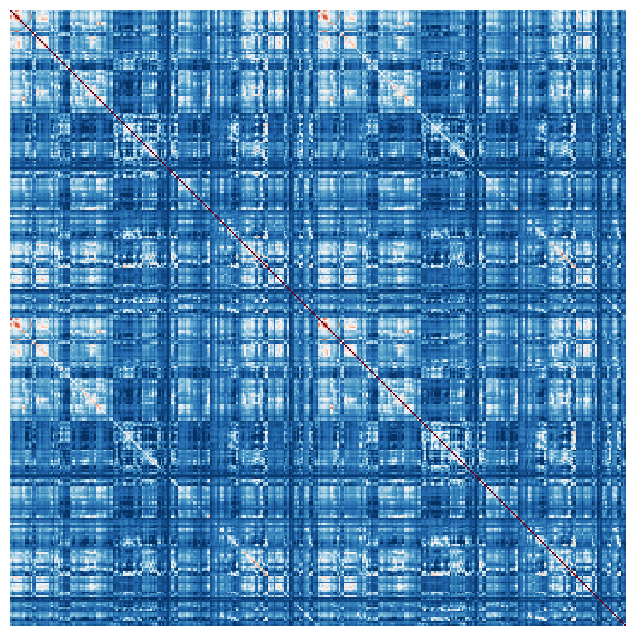

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
matrix_plot_2(ax, fc, 'RdBu_r')

### PMC Sample Data

In [63]:
from hbnm.io import Data
import h5py

filepath = 'heterogeneous/iteration_2.hdf5'

In [64]:
data_handler = Data("data/", "outputs/")
iter_data = data_handler.load(filepath, from_output=True)

In [65]:
iter_data.keys()

<KeysViewHDF5 ['distance', 'epsilon', 'ess', 'n_accepted', 'n_total', 'tau_squared', 'theta', 'weights']>

In [69]:
theta = iter_data['theta'][:]
theta.shape

(5, 25)

In [70]:
# Explore the distribution of each parameter

w_EI = theta[0,:]  # w_EI minimum values
w_EI_slope = theta[1,:]  # w_EI scale/slope values  
w_EE = theta[2,:]  # w_EE minimum values
w_EE_slope = theta[3,:]  # w_EE scale/slope values
G = theta[4,:]  # Global coupling parameter

array([4.02585038, 5.86603567, 2.41115824, 4.93673351, 4.16255115,
       2.49967229, 2.96258172, 2.9580016 , 4.1494235 , 3.39802177,
       6.84727915, 5.38258817, 4.21316205, 2.79296498, 1.93860952,
       6.07645267, 5.27535545, 4.83229053, 5.14714724, 3.83926071,
       6.57276504, 2.35174268, 4.93478381, 4.50970724, 4.45986628])

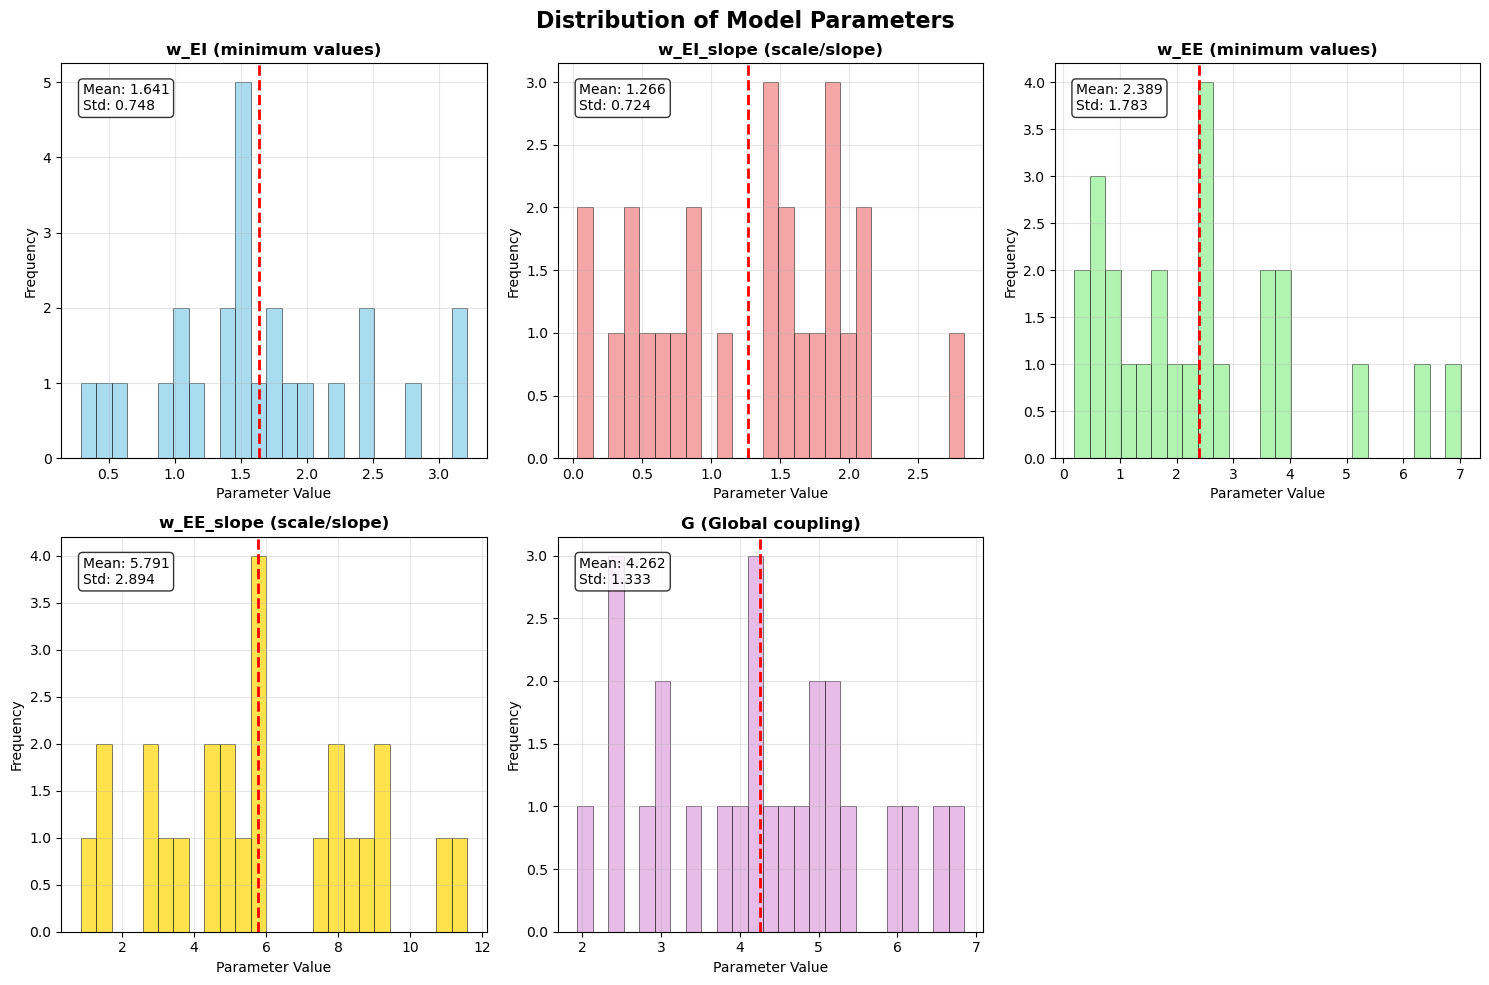

Parameter Summary Statistics:
w_EI (minimum values):
  Mean: 1.640656
  Std:  0.747920
  Min:  0.289310
  Max:  3.213342
  Range: 2.924032
------------------------------
w_EI_slope (scale/slope):
  Mean: 1.265521
  Std:  0.723648
  Min:  0.032403
  Max:  2.831512
  Range: 2.799109
------------------------------
w_EE (minimum values):
  Mean: 2.389245
  Std:  1.783317
  Min:  0.192435
  Max:  7.008562
  Range: 6.816127
------------------------------
w_EE_slope (scale/slope):
  Mean: 5.791436
  Std:  2.893780
  Min:  0.853720
  Max:  11.592125
  Range: 10.738405
------------------------------
G (Global coupling):
  Mean: 4.261760
  Std:  1.332962
  Min:  1.938610
  Max:  6.847279
  Range: 4.908670
------------------------------


In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 5 subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Model Parameters', fontsize=16, fontweight='bold')

# Flatten axes array for easier indexing
axes = axes.flatten()

# Parameter data and labels
parameters = [w_EI, w_EI_slope, w_EE, w_EE_slope, G]
param_names = ['w_EI (minimum values)', 'w_EI_slope (scale/slope)', 'w_EE (minimum values)', 
               'w_EE_slope (scale/slope)', 'G (Global coupling)']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

# Create histograms for each parameter
for i, (param, name, color) in enumerate(zip(parameters, param_names, colors)):
    axes[i].hist(param, bins=25, alpha=0.7, color=color, edgecolor='black', linewidth=0.5)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Parameter Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    # Add statistics text
    mean_val = np.mean(param)
    std_val = np.std(param)
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    axes[i].text(0.05, 0.95, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove the 6th subplot (we only have 5 parameters)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# Print summary statistics
print("Parameter Summary Statistics:")
print("="*50)
for param, name in zip(parameters, param_names):
    print(f"{name}:")
    print(f"  Mean: {np.mean(param):.6f}")
    print(f"  Std:  {np.std(param):.6f}")
    print(f"  Min:  {np.min(param):.6f}")
    print(f"  Max:  {np.max(param):.6f}")
    print(f"  Range: {np.max(param) - np.min(param):.6f}")
    print("-" * 30)
